# Fitting scores with ML model

### First we try to learn a ML model to fit scores to predict best variants following a simple deterministic model

In [5]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

## 1. Building a simple deterministic model for variants performance.

Variants are represented by the sequence of 7 amino-acids that are among a list of 20 different amino-acids.
We will define some arbitrary rules to express a better viability and a better selectivity.
Then the model will just face the results and will try to fit the scores for viability and selectivity (cf full_DE_loopV1.ipynb).

In [6]:
key = jax.random.key(42)
key_seq, key_viab_w, key_sel_w, key_n0, key_run = jax.random.split(key, 5)

num_sequences   = 10000
num_positions   = 7     # L
num_amino_acids = 20

# Random library: sequences and initial read counts
sequences = jax.random.randint(
    key_seq, shape=(num_sequences, num_positions),
    minval=0, maxval=num_amino_acids
)

""" 
Before the weights that define the model were randomized, we are going to build these matrices to help some variants
"""
# Two independent score matrices
# viability_weights   = jax.random.normal(key_viab_w, shape=(num_amino_acids, num_positions))
# selectivity_weights = jax.random.normal(key_sel_w,  shape=(num_amino_acids, num_positions))

n0 = jax.random.randint(
    key_n0, shape=(num_sequences,), minval=10, maxval=1000
).astype(jnp.float32)

print(f"Library: {num_sequences} sequences of length {num_positions}")
print(f"First sequences:\n{sequences[:3]}")


Library: 10000 sequences of length 7
First sequences:
[[ 4 11 19  1 10 19  0]
 [ 9  8 11 16  1  2  7]
 [11  4 19  7  3 19 13]]


### Building the weights matrices

**GT = ground truth**

Shape: `(num_amino_acids, num_positions)` = 20 × 7.  
AA indices run 0–19, positions run 0–6.

---

#### Viability rules
1. **Even-row AAs preferred** — AA with even index (0,2,4,...,18) get +1.0 at every position *(parity bias)*
2. **Diagonal affinity** — AA i likes position i for i ∈ 0..6 → +2.0 on the diagonal *(positional specificity)*
3. **High-index AAs bad at position 0** — AA 15–19 penalised at the first position → -2.0 *(N-terminus constraint)*
4. **Low-index AAs bad at last position** — AA 0–4 penalised at position 6 → -1.5 *(C-terminus constraint)*
5. **Central position favours mid-range AAs** — AA 10–12 get +1.5 at position 3 *(core packing)*

---

#### Selectivity rules
1. **High-index AAs universally selective** — AA 15–19 get +1.0 at every position *(large/aromatic preference)*
2. **N-terminus specificity** — AA 5–9 get +1.5 at position 0 only *(receptor binding N-cap)*
3. **Strong C-terminal motif** — AA 0–1 get +2.0 at positions 4 and 5 *(binding loop)*
4. **Central penalty** — AA 8–12 get -1.5 at position 2 *(steric clash in binding site)*
5. **Distal positions amplified** — columns 5 and 6 are scaled ×1.5 *(exposed tip of the capsid)*
6. **Universally bad AAs** — AA 13–14 get -0.5 everywhere *(structurally incompatible)*


In [15]:
# ── Viability weights (20 × 7) ──────────────────────────────────────────────
w_viab = np.zeros((num_amino_acids, num_positions))

# Rule 1: even-indexed AAs preferred at all positions
w_viab[0::2, :] += 5.0

# Rule 2: AA i likes position i (diagonal affinity)
for i in range(num_positions):
    w_viab[i, i] += 50.0

# Rule 3: AA 15-19 bad at position 0 (N-terminus)
w_viab[15:20, 0] -= 10.0

# Rule 4: AA 0-4 bad at position 6 (C-terminus)
w_viab[0:5, 6] -= 15

# Rule 5: AA 10-12 good at center position 3
w_viab[10:13, 3] += 15

viability_weights_GT = jnp.array(w_viab)

print("Viability weights GT:")
print(jnp.round(viability_weights_GT, 2))


Viability weights GT:
[[ 55.   5.   5.   5.   5.   5. -10.]
 [  0.  50.   0.   0.   0.   0. -15.]
 [  5.   5.  55.   5.   5.   5. -10.]
 [  0.   0.   0.  50.   0.   0. -15.]
 [  5.   5.   5.   5.  55.   5. -10.]
 [  0.   0.   0.   0.   0.  50.   0.]
 [  5.   5.   5.   5.   5.   5.  55.]
 [  0.   0.   0.   0.   0.   0.   0.]
 [  5.   5.   5.   5.   5.   5.   5.]
 [  0.   0.   0.   0.   0.   0.   0.]
 [  5.   5.   5.  20.   5.   5.   5.]
 [  0.   0.   0.  15.   0.   0.   0.]
 [  5.   5.   5.  20.   5.   5.   5.]
 [  0.   0.   0.   0.   0.   0.   0.]
 [  5.   5.   5.   5.   5.   5.   5.]
 [-10.   0.   0.   0.   0.   0.   0.]
 [ -5.   5.   5.   5.   5.   5.   5.]
 [-10.   0.   0.   0.   0.   0.   0.]
 [ -5.   5.   5.   5.   5.   5.   5.]
 [-10.   0.   0.   0.   0.   0.   0.]]


In [16]:
# ── Selectivity weights (20 × 7) ────────────────────────────────────────────
w_sel = np.zeros((num_amino_acids, num_positions))

# Rule 1: AA 15-19 preferred at all positions
w_sel[15:20, :] += 4.0

# Rule 2: AA 5-9 favoured at position 0 only (N-terminus specificity)
w_sel[5:10, 0] += 1.5

# Rule 3: AA 0-1 strongly favoured at positions 4-5 (C-terminal binding motif)
w_sel[0:2, 4:6] += 2.0

# Rule 4: AA 8-12 penalised at position 2 (steric clash in binding site)
w_sel[8:13, 2] -= 1.5

# Rule 5: positions 5 and 6 are more exposed → amplify weights
w_sel[:, 5] *= 3
w_sel[:, 6] *= 3

# Rule 6: AA 13-14 universally bad
w_sel[13:15, :] -= 5

selectivity_weights_GT = jnp.array(w_sel)

print("Selectivity weights GT:")
print(jnp.round(selectivity_weights_GT, 2))


Selectivity weights GT:
[[ 0.   0.   0.   0.   2.   6.   0. ]
 [ 0.   0.   0.   0.   2.   6.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0. ]
 [ 1.5  0.   0.   0.   0.   0.   0. ]
 [ 1.5  0.   0.   0.   0.   0.   0. ]
 [ 1.5  0.   0.   0.   0.   0.   0. ]
 [ 1.5  0.  -1.5  0.   0.   0.   0. ]
 [ 1.5  0.  -1.5  0.   0.   0.   0. ]
 [ 0.   0.  -1.5  0.   0.   0.   0. ]
 [ 0.   0.  -1.5  0.   0.   0.   0. ]
 [ 0.   0.  -1.5  0.   0.   0.   0. ]
 [-5.  -5.  -5.  -5.  -5.  -5.  -5. ]
 [-5.  -5.  -5.  -5.  -5.  -5.  -5. ]
 [ 4.   4.   4.   4.   4.  12.  12. ]
 [ 4.   4.   4.   4.   4.  12.  12. ]
 [ 4.   4.   4.   4.   4.  12.  12. ]
 [ 4.   4.   4.   4.   4.  12.  12. ]
 [ 4.   4.   4.   4.   4.  12.  12. ]]


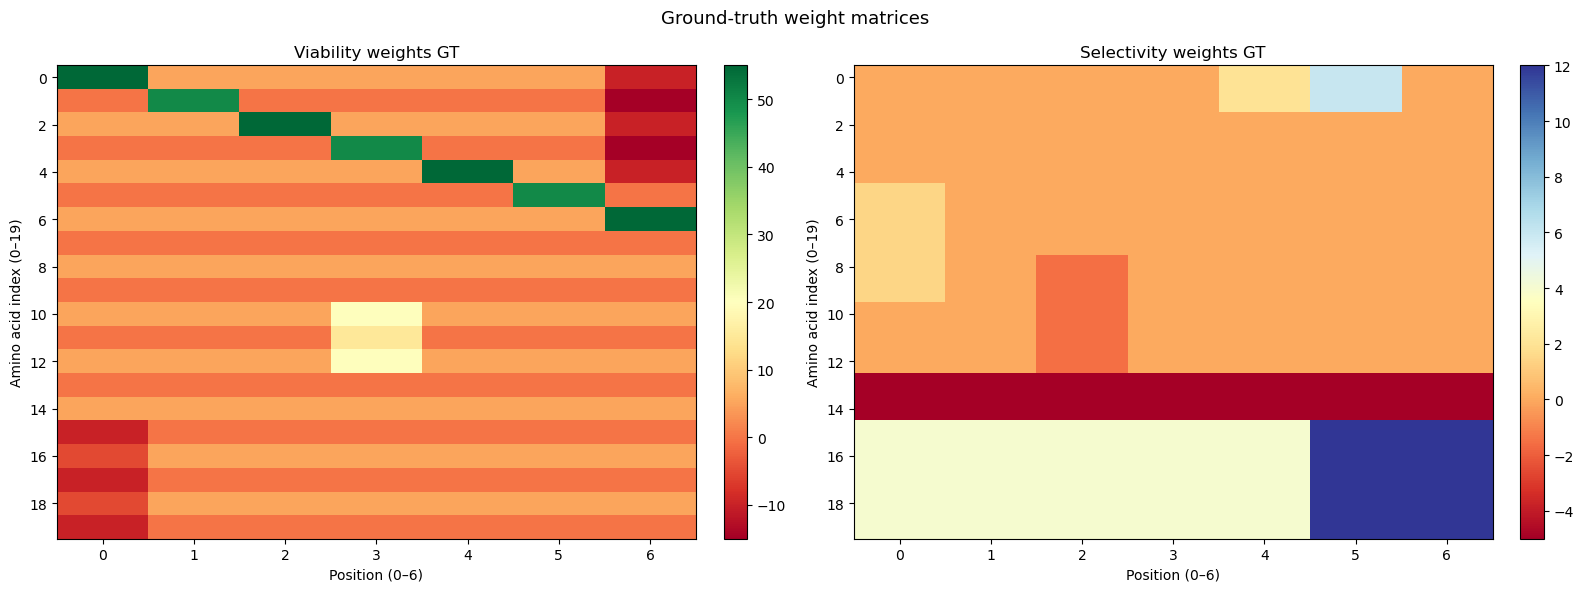

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, w, title, cmap in [
    (axes[0], viability_weights_GT,   'Viability weights GT',   'RdYlGn'),
    (axes[1], selectivity_weights_GT, 'Selectivity weights GT', 'RdYlBu'),
]:
    im = ax.imshow(np.array(w), cmap=cmap, aspect='auto',
                   vmin=float(w.min()), vmax=float(w.max()))
    ax.set_xlabel('Position (0–6)'); ax.set_ylabel('Amino acid index (0–19)')
    ax.set_xticks(range(num_positions))
    ax.set_yticks(range(0, num_amino_acids, 2))
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Ground-truth weight matrices', fontsize=13)
plt.tight_layout()
plt.show()


In [21]:
from full_DE_loopV1 import *

_, capsids, lambdap1, n2 = protocol(
    n0, sequences, 
    viability_weights_GT, 
    selectivity_weights_GT,
)

ModuleNotFoundError: No module named 'full_DE_loopV1'

## 2. Building the first MLP
